<a href="https://colab.research.google.com/github/trxmaschine/homewrks/blob/lvl-4/hw_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Импорты

In [ ]:
!pip install -U numpy
!pip install git+https://github.com/etna-team/etna

  Using cached numpy-2.3.1-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.3.1-cp311-cp311-manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
etna 3.0.0 requires numpy<2, but you have numpy 2.3.1 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.1 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.3.1 which is incompatible.


  Cloning https://github.com/etna-team/etna to /tmp/pip-req-build-ws84z39j
  Running command git clone --filter=blob:none --quiet https://github.com/etna-team/etna /tmp/pip-req-build-ws84z39j
  Resolved https://github.com/etna-team/etna to commit bf8f50956ea4c733fc4fdf9d401d4043bd6b1bb4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.1
    Uninstalling numpy-2.3.1:
      Successfully uninstalled numpy-2.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have 

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd

from etna.datasets import TSDataset
from etna.models import NaiveModel, MovingAverageModel, CatBoostMultiSegmentModel, SeasonalMovingAverageModel, SARIMAXModel
from etna.analysis import plot_forecast, acf_plot, distribution_plot, plot_correlation_matrix, plot_trend, plot_periodogram, seasonal_plot, stl_plot, plot_backtest
from etna.metrics import MAE, MSE, SMAPE
from etna.transforms import LagTransform, DateFlagsTransform, LinearTrendTransform
from etna.pipeline import Pipeline

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vitaliymalcev/russian-passenger-air-service-20072020")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/russian-passenger-air-service-20072020


In [ ]:
!ls /kaggle/input/russian-passenger-air-service-20072020

russian_air_service_CARGO_AND_PARCELS.csv  russian_passenger_air_service_2.csv


In [ ]:
df = pd.read_csv(
    '/kaggle/input/russian-passenger-air-service-20072020/russian_passenger_air_service_2.csv',
)
df.head()

,Airport name,Year,January,February,March,April,May,June,July,August,September,October,November,December,Whole year,Airport coordinates
0,Abakan,2020,13495.0,14940.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(Decimal('91.399735'), Decimal('53.751351'))"
1,Aikhal,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(Decimal('111.543324'), Decimal('65.957161'))"
2,Loss,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(Decimal('125.398355'), Decimal('58.602489'))"
3,Amderma,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(Decimal('61.577429'), Decimal('69.759076'))"
4,Anadyr (Carbon),2020,4255.0,4565.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"(Decimal('177.738273'), Decimal('64.713433'))"


#### Преобразование в длинный формат и сортировка

In [ ]:
months = [
  'January',
  'February',
  'March',
  'April',
  'May',
  'June',
  'July',
  'August',
  'September',
  'October',
  'November',
  'December',
]

df_melted = df.melt(
    id_vars=['Airport name', 'Year'], # Фиксированные столбцы
    value_vars=months,                # Столбцы, которые нужно развернуть
    var_name='Month',                 # Название нового столбца для месяцев
    value_name='Quantity'             # Название нового столбца для значений
)


month_mapping = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
# Месяцы в номера
df_melted['Month'] = df_melted['Month'].map(month_mapping)


# Сортировка df
df_sorted = df_melted.sort_values(by=['Year', 'Month'], ascending=[True, True])
df_sorted.head()

,Airport name,Year,Month,Quantity
3669,Abakan,2007,1,3680.0
3670,Aikhal,2007,1,0.0
3671,Loss,2007,1,0.0
3672,Amderma,2007,1,0.0
3673,Anadyr,2007,1,2890.0


#### Преобразование в нужный формат

In [ ]:
df_sorted['YearMonth'] = pd.to_datetime(df_sorted[["Year", "Month"]].assign(day=1), unit="m")
df_sorted.set_index('YearMonth', inplace=True)
df_sorted.head()

,Airport name,Year,Month,Quantity
YearMonth,,,,
2007-01-01,Abakan,2007,1,3680.0
2007-01-01,Aikhal,2007,1,0.0
2007-01-01,Loss,2007,1,0.0
2007-01-01,Amderma,2007,1,0.0
2007-01-01,Anadyr,2007,1,2890.0


In [ ]:
pax_count = df_sorted["Quantity"].resample('1ME').sum() / 1000
pax_count = pax_count.reset_index()
pax_count.head()

,YearMonth,Quantity
0,2007-01-31,4290.267
1,2007-02-28,3897.237
2,2007-03-31,4631.915
3,2007-04-30,5152.085
4,2007-05-31,5767.910


In [ ]:
df1 = pax_count.rename(columns={'YearMonth': 'timestamp', 'Quantity': 'target'})
df1['segment'] = 'main'
ts = TSDataset(df1, freq='M')
ts.head()


segment,main
feature,target
timestamp,
2007-01-31,4290.267
2007-02-28,3897.237
2007-03-31,4631.915
2007-04-30,5152.085
2007-05-31,5767.910


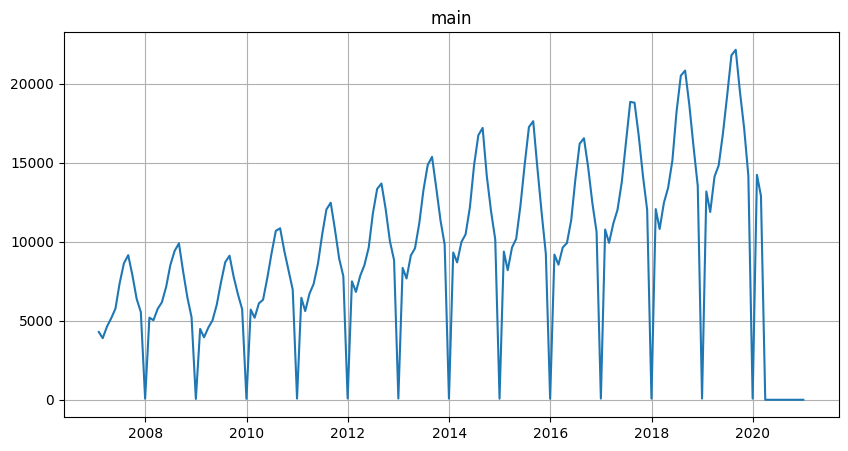

In [ ]:
ts.plot()

In [ ]:
ts.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
main,2007-01-31,2020-12-31,168,0,1,0,0,0,ME


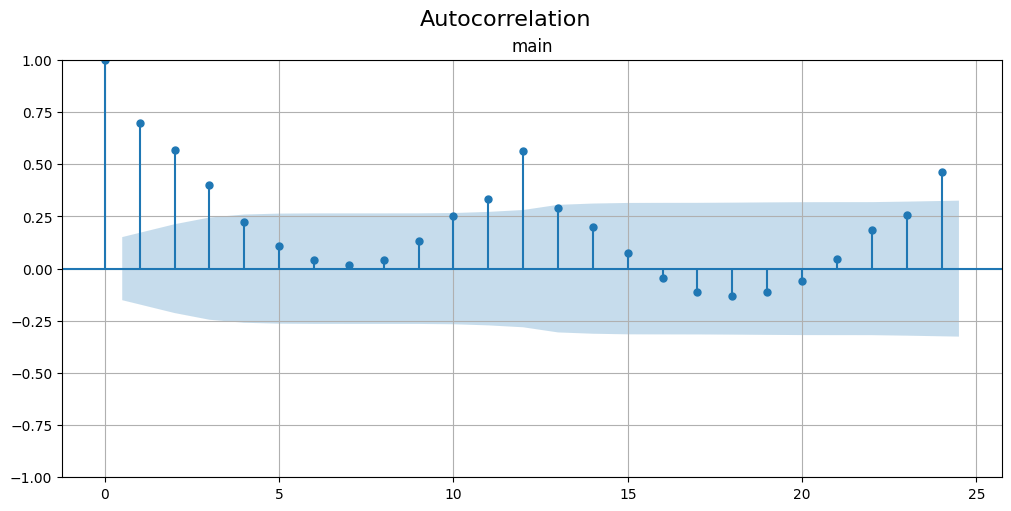

In [ ]:
acf_plot(ts, lags=24)

#### Разделение данных в DF на данные для обучения и тестовую выборку

In [ ]:
train_ts, test_ts = ts.train_test_split(
    train_start='2007-01-31',
    train_end='2017-12-31',
    test_start='2018-01-31',
    test_end='2019-12-31')

При тестируемых данных включающих 2020 год, выявленно отсуствие данных по пассажиропотоку, ввиду чего, мною был избрано предсказываемое значение - 2018- 2019.

In [ ]:
def fit_model(model, train_ts, horizon):
  model.fit(train_ts)

  future_ts = train_ts.make_future(future_steps=horizon, tail_steps=model.context_size)
  return future_ts


In [ ]:
  HORIZON = 24

Рассматриваем все ML метрики. Орентируемся на SMAPE, т.к данная метрика понятна бизнесу.

### Модель скользящего среднего - Baseline

In [ ]:
model = MovingAverageModel(window=5)
future_ts = fit_model(model, train_ts, HORIZON)
forecast_ts = model.forecast(future_ts, prediction_size=HORIZON)
forecast_ts

segment,main
feature,target
timestamp,
2018-01-31,12347.156422
2018-02-28,11058.313306
2018-03-31,9926.911768
2018-04-30,9084.299521
2018-05-31,8498.566425
2018-06-30,10183.049489
2018-07-31,9750.228102
2018-08-31,9488.611061


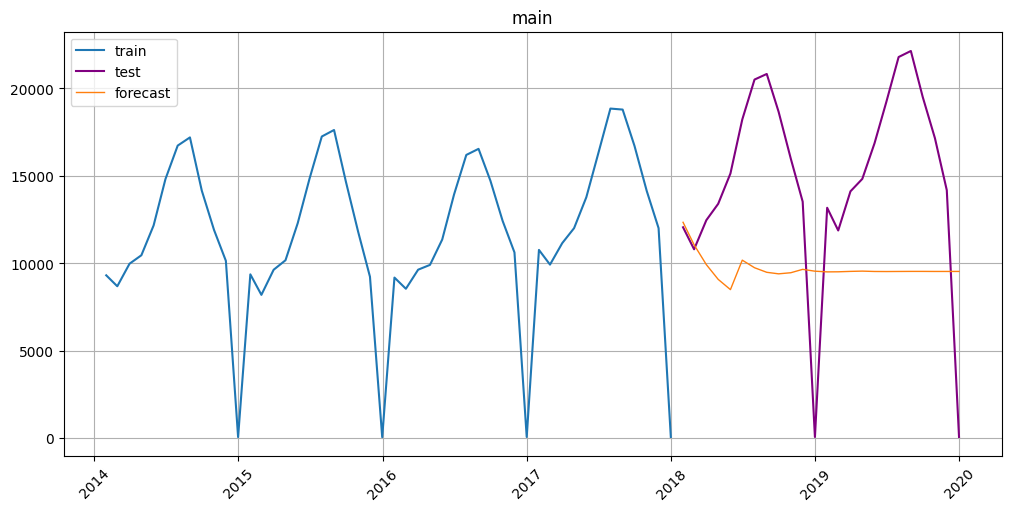

In [ ]:
plot_forecast(forecast_ts, test_ts, train_ts, n_train_samples=48)

In [ ]:
for metric in [SMAPE(), MAE(), MSE()]:
  print(f"Metric {metric.name}: {metric(y_true=test_ts, y_pred=forecast_ts)['main']}")

Metric SMAPE: 60.447643649743114
Metric MAE: 6781.947968915876
Metric MSE: 58526205.64800203


Ошибки очень критичные, сезонность прослеживается слабо и только в первый год предсказания.

### Модель сезонного среднего

In [ ]:
model = SeasonalMovingAverageModel(window=5, seasonality=12)
model.fit(train_ts)
future_ts = train_ts.make_future(future_steps=HORIZON, tail_steps=model.context_size)
forecast_ts = model.forecast(future_ts, prediction_size=HORIZON)
forecast_ts.head()

segment,main
feature,target
timestamp,
2018-01-31,9397.2332
2018-02-28,8607.5054
2018-03-31,9907.0262
2018-04-30,10429.8410
2018-05-31,12155.2286


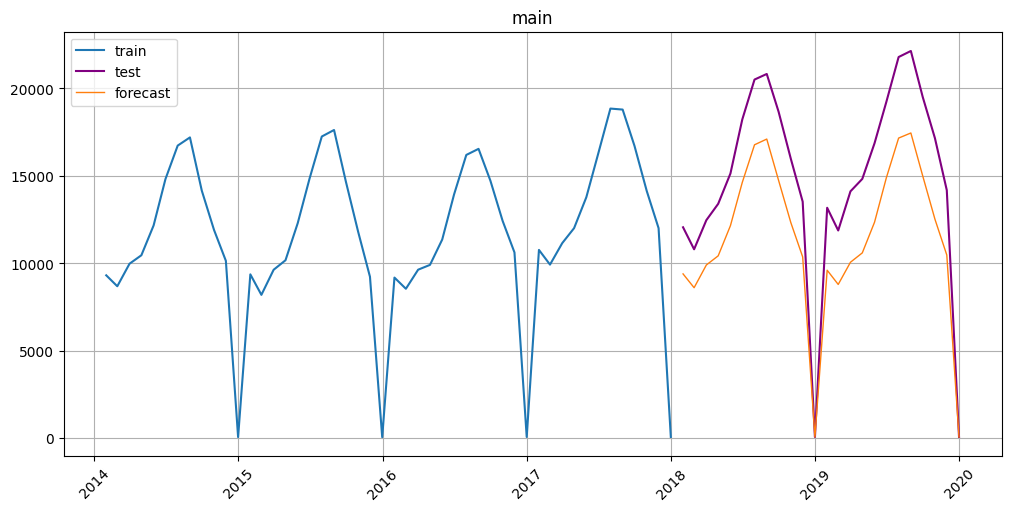

In [ ]:
plot_forecast(forecast_ts, test_ts, train_ts, n_train_samples=48)

In [ ]:
for metric in [SMAPE(), MAE(), MSE()]:
  print(f"Metric {metric.name}: {metric(y_true=test_ts, y_pred=forecast_ts)['main']}")

Metric SMAPE: 24.37595369657996
Metric MAE: 3380.3368814166665
Metric MSE: 12932396.38167944


### SARIMAX

In [ ]:
model = SARIMAXModel(order=(6, 1, 6), seasonal_order=(1, 1, 4, 12))
model.fit(train_ts)
future_ts = train_ts.make_future(HORIZON)
forecast_ts = model.forecast(future_ts)
forecast_ts.head()

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


segment,main
feature,target
timestamp,
2018-01-31,11362.434914
2018-02-28,10354.215897
2018-03-31,11691.386123
2018-04-30,12543.739869
2018-05-31,14470.433241


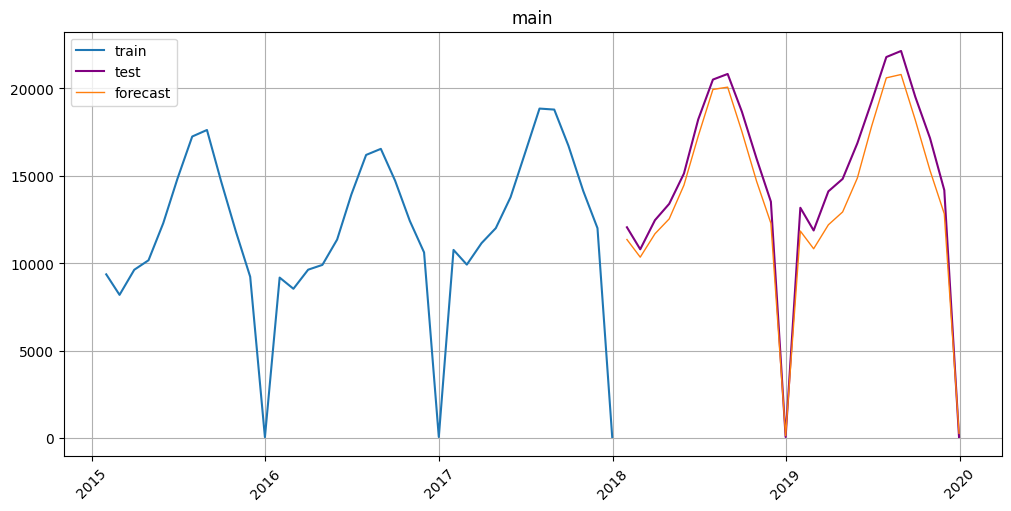

In [ ]:
plot_forecast(forecast_ts, test_ts, train_ts, n_train_samples=36)

In [ ]:
for metric in [SMAPE(), MAE(), MSE()]:
  print(f"Metric {metric.name}: {metric(y_true=test_ts, y_pred=forecast_ts)['main']}")

Metric SMAPE: 14.709973442219097
Metric MAE: 1095.862442744585
Metric MSE: 1460668.6677035391


```По модели сезонного среднего SMAPE = 24.
По SARIMAX = 15```

#### Задаем гипперпараметры




In [ ]:
!pip install "etna[auto, prophet]" -q


In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd

from etna.datasets import TSDataset
from etna.metrics import SMAPE
from etna.models import LinearPerSegmentModel, SARIMAXModel, NaiveModel, ProphetModel
from etna.pipeline import Pipeline
from etna.transforms import DateFlagsTransform
from etna.transforms import LagTransform

In [ ]:
model = LinearPerSegmentModel()
transforms = [
    LagTransform(in_column="target", lags=list(range(HORIZON, HORIZON + 10)), out_column="target_lag"),
    DateFlagsTransform(out_column="date_flags"),
]
pipeline = Pipeline(model=model, transforms=transforms, horizon=HORIZON)

In [ ]:
from etna.distributions import CategoricalDistribution

example_params_to_tune = {
    "model.fit_intercept": CategoricalDistribution(choices=[False, True]),
    "transforms.1.month_number_in_year": CategoricalDistribution(choices=[False, True]),
}

In [ ]:
pipeline.params_to_tune()

{'model.fit_intercept': CategoricalDistribution(choices=[False, True]),
 'transforms.1.day_number_in_week': CategoricalDistribution(choices=[False, True]),
 'transforms.1.day_number_in_month': CategoricalDistribution(choices=[False, True]),
 'transforms.1.day_number_in_year': CategoricalDistribution(choices=[False, True]),
 'transforms.1.week_number_in_month': CategoricalDistribution(choices=[False, True]),
 'transforms.1.week_number_in_year': CategoricalDistribution(choices=[False, True]),
 'transforms.1.month_number_in_year': CategoricalDistribution(choices=[False, True]),
 'transforms.1.season_number': CategoricalDistribution(choices=[False, True]),
 'transforms.1.year_number': CategoricalDistribution(choices=[False, True]),
 'transforms.1.is_weekend': CategoricalDistribution(choices=[False, True])}

In [ ]:
from etna.auto import Tune

tune_custom_params = Tune(
    pipeline=pipeline,
    target_metric=SMAPE(),
    horizon=HORIZON,
    backtest_params=dict(n_folds=3),
    params_to_tune=example_params_to_tune,
)

In [ ]:
import optuna

optuna.logging.set_verbosity(optuna.logging.CRITICAL)

In [ ]:
%%capture
best_pipeline_custom_params = tune_custom_params.fit(ts=ts, n_trials=20)

In [ ]:
tune_custom_params.summary()[["hash", "pipeline", "SMAPE_mean", "elapsed_time", "state"]].sort_values("SMAPE_mean").drop_duplicates(
    subset="hash"
)

,hash,pipeline,SMAPE_mean,elapsed_time,state
19,6e845150473e5aad9192e47369f090d1,Pipeline(model = LinearPerSegmentModel(fit_int...,53.141902,0.615501,1
0,e0c452acc413a0df6bef9304cdeb422f,Pipeline(model = LinearPerSegmentModel(fit_int...,53.227027,0.890108,1
7,f3edec8478200ef8d5ab7e411439223d,Pipeline(model = LinearPerSegmentModel(fit_int...,53.274724,0.595561,1
6,7f2eb02e5192c554a47840ab0790d2d0,Pipeline(model = LinearPerSegmentModel(fit_int...,53.552232,0.642617,1


In [ ]:
from etna.auto import Auto
from etna.auto import Pool

auto = Auto(
    target_metric=SMAPE(), horizon=HORIZON, pool=Pool.MS_super_fast, generate_params={}, backtest_params=dict(n_folds=3)
)

In [ ]:
custom_pool = [
    Pipeline(model=NaiveModel(lag=1), transforms=(), horizon=HORIZON),
    Pipeline(
        model=LinearPerSegmentModel(),
        transforms=[LagTransform(in_column="target", lags=list(range(HORIZON, 2 * HORIZON)), out_column="target_lag")],
        horizon=HORIZON,
    ),
    Pipeline(
        model=ProphetModel(),
        transforms=[],
        horizon=HORIZON,
    ),
    Pipeline(model=SARIMAXModel(), transforms=(), horizon=HORIZON),
]

In [ ]:
%%capture
custom_auto = Auto(
    target_metric=SMAPE(),
    horizon=HORIZON,
    pool=custom_pool,
    backtest_params=dict(n_folds=3),
    storage="sqlite:///etna-auto-custom.db",
)
best_custom_pool_pipeline = custom_auto.fit(ts=ts, tune_size=0)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpneel9_jl/c7b4kass.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpneel9_jl/v0vojnn7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=37047', 'data', 'file=/tmp/tmpneel9_jl/c7b4kass.json', 'init=/tmp/tmpneel9_jl/v0vojnn7.json', 'output', 'file=/tmp/tmpneel9_jl/prophet_model3kbtm511/prophet_model-20250629192453.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prop

In [ ]:
custom_auto.summary()[["hash", "pipeline", "SMAPE_mean", "elapsed_time", "state", "study"]].sort_values("SMAPE_mean")

,hash,pipeline,SMAPE_mean,elapsed_time,state,study
2,f2f3c5b6f2b94c20cacf9da613f95455,Pipeline(model = ProphetModel(growth = 'linear...,50.405455,0.964446,1,pool
0,d31d0ca609e9e838656b02bcc7b30c1b,Pipeline(model = LinearPerSegmentModel(fit_int...,56.103914,0.604590,1,pool
1,c800aab3ece1e1b331fe41f33a9605e1,"Pipeline(model = NaiveModel(lag = 1, ), transf...",184.678539,0.177661,1,pool
3,1e9b3129ac6d81e7b876d8cbdc932841,"Pipeline(model = SARIMAXModel(order = (1, 0, 0...",192.539123,0.383111,1,pool


In [ ]:
%%capture
best_custom_tuning_pipeline = custom_auto.fit(ts=ts, tune_size=2, n_trials=10, gc_after_trial=True, catch=(Exception,))

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpneel9_jl/ch4chu0k.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpneel9_jl/rrijtel5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=46256', 'data', 'file=/tmp/tmpneel9_jl/ch4chu0k.json', 'init=/tmp/tmpneel9_jl/rrijtel5.json', 'output', 'file=/tmp/tmpneel9_jl/prophet_modeluu1p4e6d/prophet_model-20250629192533.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prop

In [ ]:
custom_auto.summary()[["hash", "pipeline", "SMAPE_mean", "elapsed_time", "state", "study"]].sort_values(
    "SMAPE_mean"
).drop_duplicates(subset=("hash", "study"))

,hash,pipeline,SMAPE_mean,elapsed_time,state,study
8,92c3e012a16960961317e226006d2d55,Pipeline(model = ProphetModel(growth = 'linear...,38.477737,2.297636,1,tuning/f2f3c5b6f2b94c20cacf9da613f95455
7,6239bc7ebddccaa72cc0e7d06e72d8b9,Pipeline(model = ProphetModel(growth = 'linear...,42.956838,1.099233,1,tuning/f2f3c5b6f2b94c20cacf9da613f95455
6,f5f473da9f6affb1ef24f508611d3f01,Pipeline(model = LinearPerSegmentModel(fit_int...,44.521223,0.582931,1,tuning/d31d0ca609e9e838656b02bcc7b30c1b
2,f2f3c5b6f2b94c20cacf9da613f95455,Pipeline(model = ProphetModel(growth = 'linear...,50.405455,0.964446,1,pool
0,d31d0ca609e9e838656b02bcc7b30c1b,Pipeline(model = LinearPerSegmentModel(fit_int...,56.103914,0.604590,1,pool
5,d31d0ca609e9e838656b02bcc7b30c1b,Pipeline(model = LinearPerSegmentModel(fit_int...,56.103914,0.580163,1,tuning/d31d0ca609e9e838656b02bcc7b30c1b
1,c800aab3ece1e1b331fe41f33a9605e1,"Pipeline(model = NaiveModel(lag = 1, ), transf...",184.678539,0.177661,1,pool
3,1e9b3129ac6d81e7b876d8cbdc932841,"Pipeline(model = SARIMAXModel(order = (1, 0, 0...",192.539123,0.383111,1,pool


In [ ]:
custom_auto.top_k(k=3)

[Pipeline(model = ProphetModel(growth = 'linear', changepoints = None, n_changepoints = 25, changepoint_range = 0.9187587557123996, yearly_seasonality = 'auto', weekly_seasonality = 'auto', daily_seasonality = 'auto', holidays = None, seasonality_mode = 'multiplicative', seasonality_prior_scale = 7.780155576901417, holidays_prior_scale = 0.3860866271460545, changepoint_prior_scale = 0.01083670267174957, mcmc_samples = 0, interval_width = 0.8, uncertainty_samples = 1000, stan_backend = None, additional_seasonality_params = (), timestamp_column = None, ), transforms = [], horizon = 24, ),
 Pipeline(model = ProphetModel(growth = 'linear', changepoints = None, n_changepoints = 25, changepoint_range = 0.8635482199008357, yearly_seasonality = 'auto', weekly_seasonality = 'auto', daily_seasonality = 'auto', holidays = None, seasonality_mode = 'multiplicative', seasonality_prior_scale = 0.6431172050131991, holidays_prior_scale = 0.8663279761354559, changepoint_prior_scale = 0.02955448301280477

In [ ]:
%%capture
best_custom_pool_metrics = best_custom_pool_pipeline.backtest(ts=ts, metrics=[SMAPE()], n_folds=3)["metrics"]
best_custom_tuning_metrics = best_custom_tuning_pipeline.backtest(ts=ts, metrics=[SMAPE()], n_folds=3)["metrics"]

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpneel9_jl/4wdy3bys.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpneel9_jl/hx47ly43.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=25579', 'data', 'file=/tmp/tmpneel9_jl/4wdy3bys.json', 'init=/tmp/tmpneel9_jl/hx47ly43.json', 'output', 'file=/tmp/tmpneel9_jl/prophet_model2k_yd05l/prophet_model-20250629192633.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prop

In [ ]:
best_custom_pool_smape = best_custom_pool_metrics["SMAPE"].mean()
best_custom_tuning_smape = best_custom_tuning_metrics["SMAPE"].mean()
print(f"Best pool SMAPE: {best_custom_pool_smape:.3f}")
print(f"Best tuning SMAPE: {best_custom_tuning_smape:.3f}")

Best pool SMAPE: 50.405
Best tuning SMAPE: 38.478
